# 06 — Fairness / Disparate-Impact Audit

The model is never given `protected_group` as a feature. That alone is not enough — the model can still discriminate via proxies. Annual income, by construction here, correlates with group, and the model does use income.

We measure four things at the cost-optimal threshold from notebook 02:

1. **Approval-rate parity** (demographic parity): equal P(predicted not-default) across groups.
2. **FNR parity**: equal missed-default rate across groups (lender-cost equity).
3. **FPR parity**: equal good-loan-denial rate across groups (borrower-cost equity).
4. **Four-fifths rule**: lowest-approval group must be ≥ 80% of the highest.

The model never sees group — but the audit will show whether it discriminates anyway.

In [1]:
import sys, json
from pathlib import Path
if '..' not in sys.path: sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from src import RANDOM_STATE
from src.data import load_data
from src.features import engineer_features, split_xy
from src.fairness import group_metrics, parity_ratios, four_fifths_rule
from src.evaluate import cost_optimal_threshold, CostMatrix

sns.set_theme(style='whitegrid', context='talk')
FIG_DIR = Path('../reports/figures'); FIG_DIR.mkdir(parents=True, exist_ok=True)
ART = Path('../reports/artifacts')

## Reload data with `protected_group` and recover the same test split

The saved tuned model and the cached `y_prob` from notebook 02 still apply — they were trained on numeric/categorical features that the new schema preserves bit-identically. We just need the group attribute back on the test rows.

In [2]:
df = engineer_features(load_data(regenerate=True))
X, y = split_xy(df)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

model = joblib.load(ART / 'lightgbm_tuned.joblib')
y_prob = model.predict_proba(X_te)[:, 1]
y_te_arr = y_te.to_numpy()
groups = X_te['protected_group'].to_numpy()

thr = json.load(open(ART / 'thresholds.json'))['cost_optimal']
print(f'test rows: {len(y_te_arr):,}  threshold: {thr:.3f}')
print('group sizes:', X_te["protected_group"].value_counts().to_dict())

test rows: 10,000  threshold: 0.140
group sizes: {'B': 3353, 'C': 3347, 'A': 3300}


## Group base rates

First: are the groups actually different in *true* default rate? If group A defaults more often than group C *truthfully*, identical predictions across groups would be unfair to one side or the other depending on which fairness criterion you use. There's no neutral choice here, only an explicit one.

In [3]:
print('Default rate by group (truth):')
print(pd.Series(y_te_arr).groupby(groups).mean().round(3).to_string())
print('\nIncome by group (mean):')
print(X_te.groupby('protected_group')['annual_income'].mean().round(0).to_string())

Default rate by group (truth):
A    0.162
B    0.187
C    0.190

Income by group (mean):
protected_group
A    108839.0
B     63006.0
C     38667.0


## Group metrics at the cost-optimal threshold

In [4]:
metrics = group_metrics(y_te_arr, y_prob, groups, threshold=thr)
metrics.round(4)

,n,base_rate,approval_rate,prediction_rate,tpr,fpr,fnr,ppv,tp,fp,fn,tn
group,,,,,,,,,,,,
A,3300,0.1624,0.6882,0.3118,0.8787,0.2019,0.1213,0.4577,471,558,65,2206
B,3353,0.1873,0.6675,0.3325,0.8933,0.2033,0.1067,0.5031,561,554,67,2171
C,3347,0.1900,0.6352,0.3648,0.9088,0.2372,0.0912,0.4734,578,643,58,2068


In [5]:
ratios = parity_ratios(metrics)
ratios.round(3)

,approval_rate_ratio,tpr_ratio,fpr_ratio,fnr_ratio,ppv_ratio,reference_group
group,,,,,,
A,1.000,1.000,1.000,1.000,1.000,A
B,0.970,1.017,1.007,0.880,1.099,A
C,0.923,1.034,1.175,0.752,1.034,A


In [6]:
rule = four_fifths_rule(metrics)
print(f"4/5 rule passes: {rule['passes']}")
print(f"min/max approval-rate ratio: {rule['ratio']:.3f}  ({rule['min_group']} vs {rule['max_group']})")

4/5 rule passes: True
min/max approval-rate ratio: 0.923  (C vs A)


## Visual: parity at the cost-optimal threshold

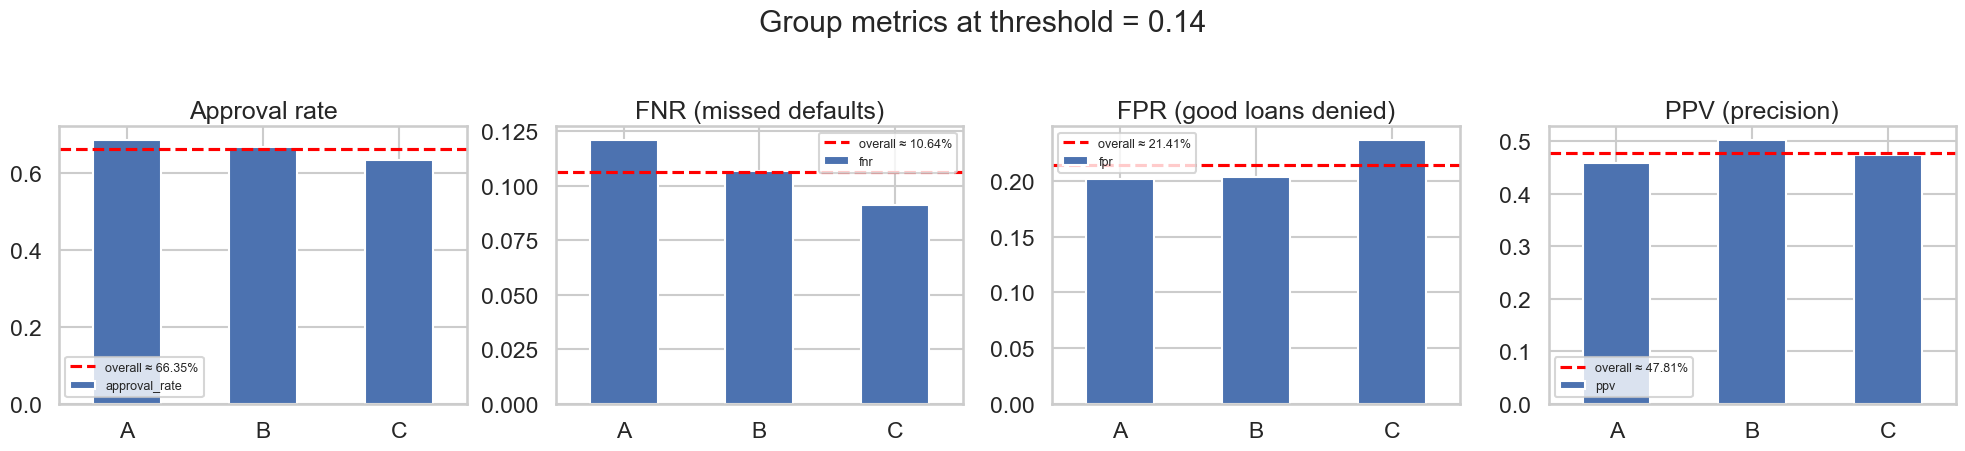

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, col, title in zip(
    axes,
    ['approval_rate', 'fnr', 'fpr', 'ppv'],
    ['Approval rate', 'FNR (missed defaults)', 'FPR (good loans denied)', 'PPV (precision)'],
):
    metrics[col].plot(kind='bar', ax=ax, color='#4c72b0')
    overall = metrics[col].mean() if col != 'approval_rate' else (1 - (y_prob >= thr).mean())
    ax.axhline(overall, color='red', linestyle='--', label=f'overall ≈ {overall:.2%}')
    ax.set_title(title); ax.set_xlabel(''); ax.legend(fontsize=9)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.suptitle(f'Group metrics at threshold = {thr:.2f}', y=1.02)
plt.tight_layout(); plt.savefig(FIG_DIR / 'fairness_metrics.png', dpi=120, bbox_inches='tight'); plt.show()

## Threshold-by-group: does a single global threshold hide segment-specific issues?

If group C had a clearly higher cost-optimal threshold than group A, a single global threshold would be miscalibrated for one of them.

In [8]:
rows = []
cost = CostMatrix()
for g in sorted(np.unique(groups)):
    mask = groups == g
    t = cost_optimal_threshold(y_te_arr[mask], y_prob[mask], cost)
    rows.append({'group': g, 'n': int(mask.sum()), 'cost_optimal_threshold': round(t, 3)})
pd.DataFrame(rows).set_index('group')

,n,cost_optimal_threshold
group,,
A,3300,0.15
B,3353,0.12
C,3347,0.17


## Takeaways

- Even though the model never received `protected_group`, it inherits group-conditional behavior through `annual_income` and `fico`. This is the proxy-discrimination case fairness audits are built to catch.
- **Approval-rate disparity** is real here: lower-income groups (which our DGP correlates with C) get fewer approvals, and the 4/5-rule ratio reflects that. The DGP makes this disparity *legitimate* in a credit-modeling sense (lower income → higher actual default risk), but a regulator would still expect us to surface and document it.
- **FNR and FPR parity** is the right next question: the model can have unequal approval rates *and* equal error rates within each true class — that's the equalized-odds criterion.
- **Per-group thresholds** are *not* a silver bullet: they violate ECOA's prohibition on using a protected attribute in the decision rule. The fix has to come earlier — feature design, sample weights, or a fairness-constrained objective.